# Train U-Net (resnet34 + ImageNet) บนชุดข้อมูล CULane

การทดลองนี้ใช้ **encoder = resnet34**, **weights = imagenet**, batch size 32, 30 epochs

**วิธีใช้:** รันเซลล์ตามลำดับจากบนลงล่าง ถ้าอยากเปลี่ยนค่าให้แก้ที่เซลล์ CONFIG (🔧) อย่างเดียว

**ข้อควรระวัง**
- **kernel ต้องอยู่ที่โฟลเดอร์โปรเจกต์** เพราะ path ของ `models/` และ `results/` เป็น relative path
- notebook นี้ **ไม่แก้ `dataset.py`** เลย การ normalize ทำในนี้ทั้งหมด เพื่อให้การทดลองเก่ายังทำซ้ำได้เหมือนเดิม
- ปิดแท็บหรือปิดคอมได้ kernel ยังรันต่อบนเซิร์ฟเวอร์

**สิ่งที่ต่างจาก `train_unet_model.ipynb`**
1. ใส่ **ImageNet normalization** (mean/std) ให้ตรงกับที่ encoder ถูก pretrain มา
2. โหลดข้อมูลแบบขนาน (`num_workers`) + **AMP (mixed precision)** + **channels_last**
3. เซฟโมเดลตอนเทรนจบเป็น `models/unet_lane_model_{exp_name}.pth`
4. มีเซลล์ **วัดผลบนชุด test** (`test_list.csv`) ซึ่งเดิมโปรเจกต์นี้ไม่มี

**เวลาที่ใช้ (วัดจากเครื่องนี้จริง):** 0.366 วินาที/step ที่ bs32 ใช้ VRAM ราว 10 GB
- เทรนเต็ม 61,182 รูป × 30 epochs ≈ **6 ชั่วโมง**
- ตั้ง `LIMIT_TRAIN = 2000` เพื่อลองก่อน ≈ **13–15 นาที** (ไฟล์ผลลัพธ์แยกชื่อ ไม่ทับรอบเต็ม)

In [ ]:
!pip install opencv-python matplotlib numpy segmentation-models-pytorch tqdm kornia

In [ ]:
import os

# ต้องตั้งก่อน import torch — ช่วยลดปัญหา memory fragmentation ตอนใช้ batch size ใหญ่
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys
import csv

if sys.stdout and hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import cv2

# ปิด thread ภายในของ OpenCV
# เพราะ DataLoader จะแตก worker หลาย process อยู่แล้ว ถ้าปล่อยให้ cv2 แตก thread เองอีก
# จะแย่ง CPU กันเอง (container นี้ถูกจำกัดไว้แค่ 4 cores)
cv2.setNumThreads(0)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import segmentation_models_pytorch as smp

import numpy as np     # เซลล์นี้เดิมไม่ได้ import numpy — ตอนนี้ลูป val ต้องใช้

sys.path.append('.')  # ให้ Python เห็นไฟล์ dataset.py ในโฟลเดอร์เดียวกัน
from dataset import LaneDatasetFromCSV, IMG_SIZE

# วัดมุมเลนระหว่างเทรน — สูตรอยู่ที่ slope_metrics.py ที่เดียว ห้ามก๊อปมาไว้ในเซลล์
from slope_metrics import extract_lanes, slope_metrics_for_lanes

print("import สำเร็จ")
print(f"torch {torch.__version__} | CUDA พร้อมใช้: {torch.cuda.is_available()}")
print(f"smp {smp.__version__} | IMG_SIZE ที่ dataset.py ใช้: {IMG_SIZE} (สูง, กว้าง)")
print(f"working directory: {os.getcwd()}")

## ฟังก์ชัน metric (IoU, Precision, Recall, F1)

ใช้สูตรเดียวกับ `train_unet_model.ipynb` เป๊ะๆ เพื่อให้ตัวเลขเทียบกับผลการทดลองเก่าใน `results/` ได้

In [ ]:
def calculate_iou(outputs, labels, threshold=0.5):
    preds = torch.sigmoid(outputs) > threshold
    labels = labels > threshold
    intersection = (preds & labels).float().sum((1, 2, 3))
    union = (preds | labels).float().sum((1, 2, 3))
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()


def calculate_precision_recall_f1(outputs, labels, threshold=0.5, eps=1e-6):
    preds = torch.sigmoid(outputs) > threshold
    labels = labels > threshold
    tp = (preds & labels).float().sum((1, 2, 3))
    fp = (preds & ~labels).float().sum((1, 2, 3))
    fn = (~preds & labels).float().sum((1, 2, 3))
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)
    return precision.mean().item(), recall.mean().item(), f1.mean().item()

print("ฟังก์ชัน metric พร้อมแล้ว")

## Loss function (BCE + Dice)

⚠️ **จุดสำคัญ:** `DiceLoss` ต้อง cast เป็น `float()` (fp32) ก่อนคำนวณ

ตอนใช้ AMP ค่า output จะเป็น fp16 การ `.sum()` ค่าประมาณ 11.5 ล้านตัว (32 × 448 × 800)
จะได้ผลรวมราว 1.1e7 ซึ่ง **ทะลุเพดานของ fp16 (65504)** แล้วกลายเป็น `inf` → loss เป็น NaN
เทรนไม่ขึ้นเลย

ทดสอบบนเครื่องนี้แล้วเกิดขึ้นจริง: แบบเดิม `.sum()` ได้ `inf` แต่แบบ upcast ได้ `10924882.0`
ส่วน `BCEWithLogitsLoss` ปลอดภัยกับ AMP อยู่แล้ว

In [ ]:
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        # .float() คือหัวใจ: กัน fp16 overflow ตอนรวมค่า (ดูคำอธิบายในเซลล์ markdown ด้านบน)
        inputs = torch.sigmoid(inputs.float()).view(-1)
        targets = targets.float().view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice

print("DiceLoss พร้อมแล้ว (upcast fp32 กัน overflow ตอนใช้ AMP)")

## เตรียม input: ImageNet normalization + channels_last

**1) normalization** — `dataset.py` ส่งรูปออกมาเป็นช่วง `[0, 1]` เฉยๆ (หาร 255) **ไม่มี** การ
normalize ด้วย mean/std แต่ encoder ที่ pretrain จาก ImageNet คาดหวัง input ที่ normalize แล้ว
เราจึงทำ **ในนี้** (ไม่ไปแก้ `dataset.py`) โดยทำ **หลัง** ย้ายขึ้น GPU และ **หลัง** augmentation
ของ dataset (ซึ่ง clamp ค่าไว้ใน `[0, 1]` แล้ว) — **ใช้กับรูปเท่านั้น ห้ามใช้กับ mask**

**2) channels_last** — เปลี่ยน memory layout ให้ conv ใช้ tensor core ได้เต็มที่
ผลลัพธ์เหมือนเดิมทางคณิตศาสตร์ แต่วัดบนเครื่องนี้ได้ **เร็วขึ้น 1.46 เท่า**
(0.535 → 0.366 วินาที/step ทำให้ 30 epochs ลดจาก ~8.5 ชม. เหลือ ~5.8 ชม.)

ทั้งสองอย่างต้องทำเหมือนกันทั้ง train / val / test จึงรวมไว้ในฟังก์ชันเดียว

In [9]:
def get_norm_stats(encoder_name, encoder_weights):
    """ดึงค่า mean/std ที่ encoder ตัวนั้น pretrain มา ถ้าดึงไม่ได้ก็ใช้ค่ามาตรฐาน ImageNet"""
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    try:
        params = smp.encoders.get_preprocessing_params(encoder_name, pretrained=encoder_weights)
        if params.get('mean'):
            mean = tuple(params['mean'])
        if params.get('std'):
            std = tuple(params['std'])
    except Exception as e:
        print(f"⚠️ ดึง preprocessing params จาก smp ไม่ได้ ({e}) — ใช้ค่ามาตรฐาน ImageNet แทน")
    return mean, std


def make_input_prep(encoder_name, encoder_weights, device,
                    normalize=True, channels_last=False):
    """
    คืนฟังก์ชันเตรียม input สำหรับรูป (batch, 3, H, W) — ใช้กับรูปเท่านั้น ไม่ใช้กับ mask

    normalize=False ใช้ตอนประเมินโมเดลเก่าที่เทรนมาด้วย input [0,1] แบบไม่ normalize
    """
    mean_t = std_t = None
    if normalize:
        mean, std = get_norm_stats(encoder_name, encoder_weights)
        mean_t = torch.tensor(mean, device=device).view(1, 3, 1, 1)
        std_t = torch.tensor(std, device=device).view(1, 3, 1, 1)
        print(f"🎨 normalize ด้วย mean={mean}, std={std}")
    else:
        print("🎨 ไม่ normalize (ใช้ input ช่วง [0,1] ตรงๆ)")

    print(f"🧭 memory format: {'channels_last' if channels_last else 'contiguous (ปกติ)'}")

    def prep(images):
        if mean_t is not None:
            images = (images - mean_t) / std_t
        if channels_last:
            images = images.contiguous(memory_format=torch.channels_last)
        return images

    return prep

print("ฟังก์ชันเตรียม input พร้อมแล้ว")

ฟังก์ชันเตรียม input พร้อมแล้ว


## ฟังก์ชันวาดกราฟ

In [ ]:
def save_plot(history_train_loss, history_val_loss,
              history_train_iou, history_val_iou,
              history_train_recall, history_val_recall,
              history_train_f1, history_val_f1,
              graph_path, history_val_slope=None):
    # 5 พาเนลถ้ามีมุมเลน (ไม่งั้น 4 เหมือนเดิม) — ต้องเป็น 2x3 เพราะ 2x2 ใส่ไม่พอ
    has_slope = history_val_slope is not None and any(
        v == v for v in history_val_slope)          # v == v คัด NaN ออก
    rows, cols = (2, 3) if has_slope else (2, 2)
    plt.figure(figsize=(18, 10) if has_slope else (12, 10))

    plt.subplot(rows, cols, 1)
    plt.plot(history_train_loss, label='Train Loss', color='red')
    plt.plot(history_val_loss, label='Val Loss', color='orange')
    plt.title('Loss History')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(rows, cols, 2)
    plt.plot(history_train_iou, label='Train Accuracy (IoU)', color='green')
    plt.plot(history_val_iou, label='Val Accuracy (IoU)', color='blue')
    plt.title('Accuracy (IoU) History')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(rows, cols, 3)
    plt.plot(history_train_recall, label='Train Recall', color='purple')
    plt.plot(history_val_recall, label='Val Recall', color='magenta')
    plt.title('Recall History')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(rows, cols, 4)
    plt.plot(history_train_f1, label='Train F1-score', color='teal')
    plt.plot(history_val_f1, label='Val F1-score', color='navy')
    plt.title('F1-score History')
    plt.xlabel('Epoch')
    plt.legend()

    if has_slope:
        plt.subplot(rows, cols, 5)
        plt.plot(history_val_slope, label='Val slope error', color='purple')
        plt.title('Lane angle error (median, deg)')
        plt.xlabel('Epoch')
        plt.ylabel('degrees')
        plt.legend()

    plt.tight_layout()
    plt.savefig(graph_path)
    plt.close()

print("ฟังก์ชันวาดกราฟพร้อมแล้ว")

## ฟังก์ชันเทรนหลัก

รับค่าจาก CONFIG ด้านล่าง ไม่ต้องแก้โค้ดในเซลล์นี้

**ไฟล์ที่จะได้ออกมา** (ชื่อมาจาก `exp_name = {encoder}_{weights}_bs{batch}_ep{epochs}`)

| ไฟล์ | คืออะไร |
| --- | --- |
| `models/final_result_epoch_{exp_name}.pth` | epoch สุดท้าย (มี history + optimizer + scaler) ใช้ resume |
| `models/best_model_{exp_name}.pth` | ตัวที่ `val_loss` ต่ำสุด |
| `models/unet_lane_model_{exp_name}.pth` | โมเดลตอนเทรนจบ (epoch สุดท้าย) — เซลล์ test ใช้ตัวนี้ |
| `results/metrics_{exp_name}.csv` | ตัวเลขทุก epoch |
| `results/training_history_{exp_name}.png` | กราฟ |

**เรื่อง resume:** ถ้ามี checkpoint อยู่แล้วและ `epoch >= epochs` ฟังก์ชันจะ **ข้ามการเทรนทันที**
ถ้าอยากเทรนใหม่ตั้งแต่ต้นต้องลบ `models/final_result_epoch_{exp_name}.pth` ก่อน
หรือถ้าอยากเทรนต่อให้เพิ่มค่า `EPOCHS`

In [ ]:
def _subset_indices(total, n):
    """
    เลือก n index กระจายทั่วทั้งชุดแบบ stride (หยิบทุกๆ k ตัว) คืน None ถ้าไม่ต้องจำกัด

    ใช้ Python ล้วนไม่พึ่ง numpy เพราะเซลล์ import ด้านบนไม่ได้ import numpy ไว้
    ทำไม stride ใช้ได้: train_list.csv เรียงตาม category (curve -> night -> normal) อยู่แล้ว
    การหยิบแบบ stride จึงคงสัดส่วนหมวดและกระจายทั่วทุก clip ให้เอง
    (วัดแล้ว n=2000 ครอบคลุม 519 จาก 520 clip สัดส่วนหมวดตรงกับชุดเต็มเกือบเป๊ะ)
    """
    if not n or n >= total:
        return None
    return [int(i * total / n) for i in range(n)]


def _limited(dataset, n):
    """ห่อ dataset ด้วย Subset ถ้ามีการจำกัดจำนวน คืน (dataset, index หรือ None)"""
    idx = _subset_indices(len(dataset), n)
    if idx is None:
        return dataset, None
    return torch.utils.data.Subset(dataset, idx), idx


def _cat_counts(base_ds, idx=None):
    """
    นับจำนวนรูปต่อ category
    ต้องนับเองเพราะ torch Subset ไม่มีเมธอด category_counts() ของ LaneDatasetFromCSV
    """
    if idx is None:
        return base_ds.category_counts()
    counts = {}
    for i in idx:
        c = base_ds.samples[i][1]
        counts[c] = counts.get(c, 0) + 1
    return dict(sorted(counts.items()))


def train(encoder_name, encoder_weights, epochs, batch_size, lr, dataset_root,
          num_workers=4, use_amp=True, use_normalize=True, use_channels_last=True,
          limit_train=None, limit_val=None,
          track_slope=True, slope_val_n=2000):
    exp_name = f"{encoder_name}_{encoder_weights}_bs{batch_size}_ep{epochs}"
    if limit_train:
        # ต้องติดจำนวนรูปไว้ในชื่อ ไม่งั้นไฟล์ของรอบทดลองจะไปยึดชื่อของรอบเทรนเต็ม
        # แล้วพอเทรนเต็มจริงๆ resume guard จะข้ามเงียบๆ หรือ resume ต่อจาก weights รอบทดลอง
        exp_name += f"_n{limit_train}"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = use_amp and device.type == "cuda"
    use_channels_last = use_channels_last and device.type == "cuda"

    print(f"🚀 ชิปประมวลผล: {device.type.upper()}")
    print(f"🧠 การทดลอง: encoder={encoder_name}, weights={encoder_weights}, "
          f"epochs={epochs}, batch_size={batch_size}, lr={lr}")
    print(f"⚡ AMP: {'เปิด' if use_amp else 'ปิด'} | num_workers: {num_workers}")

    img_dir = os.path.join(dataset_root, "images")
    mask_dir = os.path.join(dataset_root, "masks")
    train_csv = os.path.join(dataset_root, "train_list.csv")
    val_csv = os.path.join(dataset_root, "val_list.csv")

    for path in [img_dir, mask_dir, train_csv, val_csv]:
        if not os.path.exists(path):
            print(f"❌ ไม่พบ path ที่จำเป็น: {path}")
            return

    base_train = LaneDatasetFromCSV(train_csv, img_dir, mask_dir, augment=True)
    base_val = LaneDatasetFromCSV(val_csv, img_dir, mask_dir, augment=False)
    train_dataset, train_idx = _limited(base_train, limit_train)
    val_dataset, val_idx = _limited(base_val, limit_val)

    # โหลดข้อมูลแบบขนาน — ของเดิมไม่ได้ตั้ง num_workers ทำให้ decode ภาพ 61k รูปด้วย process เดียว
    loader_kwargs = dict(num_workers=num_workers, pin_memory=(device.type == "cuda"))
    if num_workers > 0:
        loader_kwargs.update(persistent_workers=True, prefetch_factor=2)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)

    if train_idx is not None or val_idx is not None:
        print(f"✂️  เทรนแบบ subset ไม่ใช่ข้อมูลเต็ม — ไฟล์ผลลัพธ์จะใช้ชื่อ {exp_name}")
    print(f"📚 Train: {len(train_dataset)} / {len(base_train)} รูป {_cat_counts(base_train, train_idx)}")
    print(f"   Val:   {len(val_dataset)} / {len(base_val)} รูป {_cat_counts(base_val, val_idx)}")

    model = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                     in_channels=3, classes=1).to(device)
    if use_channels_last:
        model = model.to(memory_format=torch.channels_last)

    prep_input = make_input_prep(encoder_name, encoder_weights, device,
                                 normalize=use_normalize, channels_last=use_channels_last)

    bce_criterion = nn.BCEWithLogitsLoss()
    dice_criterion = DiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    os.makedirs("models", exist_ok=True)
    os.makedirs("results/training", exist_ok=True)
    latest_ckpt_path = f"models/final_result_epoch_{exp_name}.pth"
    best_ckpt_path = f"models/best_model_{exp_name}.pth"
    best_slope_path = f"models/best_slope_model_{exp_name}.pth"
    final_model_path = f"models/unet_lane_model_{exp_name}.pth"
    csv_path = f"results/training/metrics_{exp_name}.csv"
    graph_path = f"results/training/training_history_{exp_name}.png"

    history_train_loss, history_train_iou = [], []
    history_train_recall, history_train_f1 = [], []
    history_val_loss, history_val_iou = [], []
    history_val_recall, history_val_f1 = [], []
    history_val_slope = []
    best_val_loss = float('inf')
    best_epoch = 0
    best_slope = float('inf')
    best_slope_epoch = 0
    start_epoch = 0

    # ภาพที่จะวัดมุม — ชุดเดิมทุก epoch ไม่งั้นเทียบข้าม epoch ไม่ได้
    # ใช้ stride ทั้ง val (ไม่ใช่ถ่วงหมวดให้เท่ากันแบบ slope_metrics_lab.ipynb)
    # เพราะจะเอาไปเลือกโมเดล จึงต้องสะท้อนสัดส่วนหมวดตามจริง
    n_val_items = len(val_dataset)
    if track_slope:
        k = min(slope_val_n or n_val_items, n_val_items)
        step = max(1, n_val_items // k)
        slope_idx = set(range(0, n_val_items, step))
        print(f"📐 วัดมุมเลนบน val {len(slope_idx)} / {n_val_items} ภาพ "
              f"(ชุดเดิมทุก epoch, ~{len(slope_idx) * 6.1 / 1000:.0f} วิ/epoch)")
    else:
        slope_idx = set()

    print(f"\n🎓 เริ่มการทดลอง: {exp_name}")

    if os.path.exists(latest_ckpt_path):
        ckpt = torch.load(latest_ckpt_path, map_location=device, weights_only=False)
        if ckpt['epoch'] < epochs:
            print("🔄 พบไฟล์ที่เทรนค้างไว้! resume ต่อ")
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            start_epoch = ckpt['epoch']

            # checkpoint ที่เซฟไว้ก่อนจะมี AMP อาจไม่มี key นี้ — ต้องเผื่อไว้
            if ckpt.get('scaler_state_dict') is not None:
                scaler.load_state_dict(ckpt['scaler_state_dict'])

            history_train_loss = ckpt.get('history_train_loss', [])
            history_train_iou = ckpt.get('history_train_iou', [])
            history_train_recall = ckpt.get('history_train_recall', [])
            history_train_f1 = ckpt.get('history_train_f1', [])
            history_val_loss = ckpt.get('history_val_loss', [])
            history_val_iou = ckpt.get('history_val_iou', [])
            history_val_recall = ckpt.get('history_val_recall', [])
            history_val_f1 = ckpt.get('history_val_f1', [])

            # checkpoint ที่เซฟก่อนจะมีการวัดมุมจะไม่มี key นี้
            # ต้องเติม NaN ให้ยาวเท่าลิสต์อื่น ไม่งั้นกราฟจะเหลื่อมแกน epoch
            history_val_slope = ckpt.get('history_val_slope', [])
            while len(history_val_slope) < len(history_val_loss):
                history_val_slope.append(float('nan'))

            best_val_loss = ckpt.get('best_val_loss', float('inf'))
            best_epoch = ckpt.get('best_epoch', 0)
            best_slope = ckpt.get('best_slope', float('inf'))
            best_slope_epoch = ckpt.get('best_slope_epoch', 0)
            print(f"✅ เริ่มเทรนต่อจาก Epoch {start_epoch + 1}")
        else:
            print(f"🆕 การทดลอง {exp_name} เทรนครบแล้ว ข้ามไปเลย")
            # กันเคสที่เทรนครบแต่ไฟล์โมเดลตัวจบหาย (เช่น kernel ตายตอนกำลังเซฟ)
            # ถ้าไม่กันไว้ เซลล์ test จะไม่มีไฟล์ให้โหลดตลอดไป เพราะ resume เด้งออกก่อน
            if not os.path.exists(final_model_path):
                torch.save(ckpt['model_state_dict'], final_model_path)
                print(f"💾 ไม่พบไฟล์โมเดลตัวจบ สร้างจาก checkpoint ให้แล้ว: {final_model_path}")
            return
    else:
        print("🆕 เริ่มเทรนใหม่ตั้งแต่ Epoch 1")

    if start_epoch == 0:
        with open(csv_path, "w", newline="") as f:
            csv.writer(f).writerow(["epoch", "loss", "accuracy", "recall", "f1_score",
                                    "val_loss", "val_accuracy", "val_recall", "val_f1_score",
                                    "val_slope_median"])

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = running_iou = running_recall = running_f1 = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            images = prep_input(images)     # normalize + channels_last (รูปเท่านั้น ไม่แตะ mask)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(images)

            # คำนวณ loss แบบ fp32 ชัดเจน (นอก autocast) เพื่อความปลอดภัยเรื่องตัวเลข
            outputs_f = outputs.float()
            loss = bce_criterion(outputs_f, masks) + dice_criterion(outputs_f, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            with torch.no_grad():
                metric_out = outputs_f.detach()
                _, r, f1 = calculate_precision_recall_f1(metric_out, masks)
                running_iou += calculate_iou(metric_out, masks)
            running_loss += loss.item()
            running_recall += r
            running_f1 += f1
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "f1": f"{f1:.4f}"})

        n = len(train_loader)
        epoch_train_loss = running_loss / n
        epoch_train_iou = running_iou / n
        epoch_train_recall = running_recall / n
        epoch_train_f1 = running_f1 / n

        model.eval()
        val_loss = val_iou = val_recall = val_f1 = 0.0
        slope_errs = []          # เก็บ error "รายเส้น" กองรวมกัน ไม่ใช่ median รายภาพ

        with torch.inference_mode():
            for b, (images, masks) in enumerate(
                    tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)):
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                images = prep_input(images)

                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(images)
                outputs_f = outputs.float()

                loss = bce_criterion(outputs_f, masks) + dice_criterion(outputs_f, masks)
                _, r, f1 = calculate_precision_recall_f1(outputs_f, masks)

                val_loss += loss.item()
                val_iou += calculate_iou(outputs_f, masks)
                val_recall += r
                val_f1 += f1

                # val_loader ตั้ง shuffle=False และไม่ได้ตั้ง drop_last
                # batch ที่ b จึงถือ index [b*bs, (b+1)*bs) เสมอ คำนวณสมาชิกได้เลย
                # ไม่ต้อง forward รอบสองให้เปลือง GPU
                if slope_idx:
                    base = b * batch_size
                    want = [j for j in range(masks.shape[0]) if base + j in slope_idx]
                    if want:
                        pd_np = (torch.sigmoid(outputs_f[want, 0]) > 0.5).cpu().numpy()
                        gt_np = (masks[want, 0] > 0.5).cpu().numpy()
                        for gt_one, pd_one in zip(gt_np, pd_np):
                            res = slope_metrics_for_lanes(extract_lanes(gt_one),
                                                          extract_lanes(pd_one))
                            slope_errs += [d["err"] for d in res["pairs"]]

        n_val = len(val_loader)
        epoch_val_loss = val_loss / n_val
        epoch_val_iou = val_iou / n_val
        epoch_val_recall = val_recall / n_val
        epoch_val_f1 = val_f1 / n_val
        # median แบบกองรวมทุกเส้น ให้ตรงกับ evaluate_slope และไฟล์ผลอื่นในโปรเจกต์
        # (median ของ median รายภาพ เป็นคนละค่า — CLAUDE.md บันทึกไว้ว่า 0.95 vs 1.27)
        epoch_val_slope = float(np.median(slope_errs)) if slope_errs else float('nan')

        scheduler.step(epoch_val_loss)

        history_train_loss.append(epoch_train_loss)
        history_train_iou.append(epoch_train_iou)
        history_train_recall.append(epoch_train_recall)
        history_train_f1.append(epoch_train_f1)
        history_val_loss.append(epoch_val_loss)
        history_val_iou.append(epoch_val_iou)
        history_val_recall.append(epoch_val_recall)
        history_val_f1.append(epoch_val_f1)
        history_val_slope.append(epoch_val_slope)

        _sl = "" if epoch_val_slope != epoch_val_slope else f" val_slope:{epoch_val_slope:.2f}°"
        print(f"[Epoch {epoch+1:02d}/{epochs}] loss:{epoch_train_loss:.4f} f1:{epoch_train_f1:.4f} "
              f"val_loss:{epoch_val_loss:.4f} val_f1:{epoch_val_f1:.4f}{_sl}")

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict() if use_amp else None,
            "val_loss": epoch_val_loss,
            "history_train_loss": history_train_loss,
            "history_train_iou": history_train_iou,
            "history_train_recall": history_train_recall,
            "history_train_f1": history_train_f1,
            "history_val_loss": history_val_loss,
            "history_val_iou": history_val_iou,
            "history_val_recall": history_val_recall,
            "history_val_f1": history_val_f1,
            "history_val_slope": history_val_slope,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "best_slope": best_slope,
            "best_slope_epoch": best_slope_epoch,
            "encoder_name": encoder_name,
            "encoder_weights": encoder_weights,
            "use_normalize": use_normalize,
        }, latest_ckpt_path)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            torch.save({"epoch": epoch + 1, "model_state_dict": model.state_dict(),
                        "val_loss": epoch_val_loss, "val_f1": epoch_val_f1,
                        "encoder_name": encoder_name, "encoder_weights": encoder_weights,
                        "use_normalize": use_normalize},
                       best_ckpt_path)
            print(f"   💾 val_loss ดีขึ้น ที่ epoch {epoch+1} -> เซฟ best model")

        # เกณฑ์ที่สอง: เลือกด้วยมุมเลน เซฟแยกไฟล์ ไม่ทับ best_model ของเดิม
        # เก็บทั้งคู่เพื่อเอาไปวัดบน test เทียบกันได้ว่าเกณฑ์ไหนให้โมเดลดีกว่า
        if epoch_val_slope == epoch_val_slope and epoch_val_slope < best_slope:
            best_slope = epoch_val_slope
            best_slope_epoch = epoch + 1
            torch.save({"epoch": epoch + 1, "model_state_dict": model.state_dict(),
                        "val_loss": epoch_val_loss, "val_f1": epoch_val_f1,
                        "val_slope_median": epoch_val_slope,
                        "encoder_name": encoder_name, "encoder_weights": encoder_weights,
                        "use_normalize": use_normalize},
                       best_slope_path)
            print(f"   📐 มุมเลนดีขึ้น ที่ epoch {epoch+1} ({epoch_val_slope:.2f}°) "
                  f"-> เซฟ best slope model")

        with open(csv_path, "a", newline="") as f:
            csv.writer(f).writerow([epoch + 1, epoch_train_loss, epoch_train_iou,
                                    epoch_train_recall, epoch_train_f1,
                                    epoch_val_loss, epoch_val_iou,
                                    epoch_val_recall, epoch_val_f1,
                                    epoch_val_slope])

        save_plot(history_train_loss, history_val_loss,
                  history_train_iou, history_val_iou,
                  history_train_recall, history_val_recall,
                  history_train_f1, history_val_f1,
                  graph_path, history_val_slope=history_val_slope)

    # เซฟโมเดลตอนเทรนจบ (epoch สุดท้าย) เป็น state_dict เปล่าๆ ตามรูปแบบไฟล์ unet_lane_model เดิม
    torch.save(model.state_dict(), final_model_path)

    print(f"\n🎉 เทรนจบแล้ว! 🏆 Best model อยู่ที่ epoch {best_epoch} (val_loss={best_val_loss:.4f})")
    print(f"📁 best model:  {best_ckpt_path}")
    if best_slope_epoch:
        print(f"📐 Best slope model อยู่ที่ epoch {best_slope_epoch} ({best_slope:.2f}°)")
        print(f"📁 best slope:  {best_slope_path}")
    print(f"📁 โมเดลตัวจบ:  {final_model_path}")
    print(f"📁 metrics:     {csv_path}")

## 🔧 CONFIG — แก้ตรงนี้อย่างเดียว

**ถ้าเจอ CUDA out of memory:** ให้ลด `BATCH_SIZE` เป็น `16`
(วัดบนเครื่องนี้แล้ว bs32 ใช้ VRAM ราว 10 GB ซึ่งเหลือที่พอ แต่ถ้ามีคนอื่นใช้ GPU อยู่ด้วยก็อาจไม่พอ)
จำไว้ว่าการเปลี่ยน `BATCH_SIZE` จะทำให้ `exp_name` เปลี่ยน → ชื่อไฟล์ผลลัพธ์ทุกตัวเปลี่ยนตาม

In [ ]:
# ==================== แก้ตรงนี้อย่างเดียว ====================
ENCODER_NAME = "resnet34"        # ตัวเลือก: resnet34, resnet50, timm-efficientnet-b0, mobilenet_v2
ENCODER_WEIGHTS = "imagenet"     # ตัวเลือก: imagenet, ssl (เฉพาะ resnet50), noisy-student (เฉพาะ timm-efficientnet-b0)
EPOCHS = 30
BATCH_SIZE = 32                  # ถ้า OOM ให้ลดเป็น 16
LEARNING_RATE = 1e-4
DATASET_ROOT = "/home/jovyan/shared/donut/CarDashCam/CULane"

NUM_WORKERS = 4                  # container นี้ถูกจำกัดไว้ 4 cores อย่าตั้งเกินนี้
USE_AMP = True                   # mixed precision: เร็วขึ้นและกิน VRAM น้อยลง
USE_NORMALIZE = True             # ใส่ ImageNet mean/std ให้ตรงกับ encoder ที่ pretrain มา
USE_CHANNELS_LAST = True         # วัดแล้วเร็วขึ้น 1.46 เท่า ผลลัพธ์เท่าเดิม

# --- จำกัดจำนวนรูปเพื่อลองเร็วๆ ---
# ตั้งเป็น None ทั้งคู่เพื่อเทรนเต็ม (61,182 / 12,877 รูป ใช้เวลา ~6 ชม.)
# ต้องลด val ด้วย ไม่ใช่ลดแค่ train ไม่งั้น val จะกินเวลา ~70% ของแต่ละ epoch
LIMIT_TRAIN = 2000               # None = เต็ม 61,182 รูป
LIMIT_VAL = 400                  # None = เต็ม 12,877 รูป

# --- วัดมุมเลนบน val ทุก epoch ---
# วัดแล้ว 6.1 ms/ภาพ: val เต็ม 12,877 = +40 นาทีตลอด 30 epochs ส่วน 2,000 ภาพ = +6 นาที
# ใช้ภาพ "ชุดเดิมทุก epoch" ไม่งั้นความต่างระหว่าง epoch จะปนกับ noise จากการสุ่ม
TRACK_SLOPE = True
SLOPE_VAL_N = 2000               # None = ใช้ val ทั้งหมด (ช้ากว่า)
# ================================================================

EXP_NAME = f"{ENCODER_NAME}_{ENCODER_WEIGHTS}_bs{BATCH_SIZE}_ep{EPOCHS}"
if LIMIT_TRAIN:
    EXP_NAME += f"_n{LIMIT_TRAIN}"   # ต้องตรงกับสูตรใน train() ไม่งั้นเซลล์วัดผลจะหาไฟล์ไม่เจอ

print(f"ตั้งค่าแล้ว: {ENCODER_NAME} + {ENCODER_WEIGHTS}, epochs={EPOCHS}, batch_size={BATCH_SIZE}")
if LIMIT_TRAIN or LIMIT_VAL:
    n_ep = -(-(LIMIT_TRAIN or 61182) // BATCH_SIZE)
    print(f"✂️  จำกัดจำนวนรูป: train={LIMIT_TRAIN}, val={LIMIT_VAL} "
          f"({n_ep} steps/epoch) — ตั้ง None เพื่อเทรนเต็ม")
print(f"exp_name = {EXP_NAME}")

## เช็คความพร้อมก่อนเทรนจริง (แนะนำให้รัน)

เซลล์นี้ใช้เวลาไม่ถึงนาที เอาไว้เช็คว่า
1. โหลด weights `imagenet` ของ resnet34 ได้ (ครั้งแรกจะดาวน์โหลด)
2. ขนาด output ถูกต้อง `(N, 1, 448, 800)`
3. **loss ไม่เป็น NaN/inf ตอนใช้ AMP** — เช็คว่า `DiceLoss` upcast ทำงานจริง

ถ้าเซลล์นี้ผ่าน แปลว่าไม่ต้องเสียเวลาเทรนไปเจอปัญหากลางทาง

In [13]:
def smoke_test(encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS, use_amp=USE_AMP):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = use_amp and device.type == "cuda"
    channels_last = USE_CHANNELS_LAST and device.type == "cuda"

    m = smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                 in_channels=3, classes=1).to(device)
    if channels_last:
        m = m.to(memory_format=torch.channels_last)

    prep_input = make_input_prep(encoder_name, encoder_weights, device,
                                 normalize=USE_NORMALIZE, channels_last=channels_last)

    h, w = IMG_SIZE
    images = torch.rand(2, 3, h, w, device=device)          # เลียนแบบ output ของ dataset ช่วง [0,1]
    masks = (torch.rand(2, 1, h, w, device=device) > 0.9).float()

    with torch.amp.autocast('cuda', enabled=use_amp):
        out = m(prep_input(images))
    out_f = out.float()

    loss = nn.BCEWithLogitsLoss()(out_f, masks) + DiceLoss()(out_f, masks)
    iou = calculate_iou(out_f, masks)

    print(f"output shape: {tuple(out.shape)} (คาดหวัง (2, 1, {h}, {w}))")
    print(f"output dtype ใน autocast: {out.dtype}")
    print(f"loss = {loss.item():.4f} | IoU = {iou:.4f}")

    assert tuple(out.shape) == (2, 1, h, w), "ขนาด output ไม่ถูกต้อง"
    assert torch.isfinite(loss), "loss เป็น NaN/inf — DiceLoss upcast มีปัญหา"
    print("✅ ผ่านทุกข้อ พร้อมเทรนจริง")

    del m, images, masks, out, out_f
    if device.type == "cuda":
        torch.cuda.empty_cache()


smoke_test()

🎨 normalize ด้วย mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
🧭 memory format: channels_last
output shape: (2, 1, 448, 800) (คาดหวัง (2, 1, 448, 800))
output dtype ใน autocast: torch.float16
loss = 1.7087 | IoU = 0.0935
✅ ผ่านทุกข้อ พร้อมเทรนจริง


## รันเทรนจริง — รอจนเห็น 🎉 เทรนจบแล้ว

เวลาที่ใช้ขึ้นกับ `LIMIT_TRAIN` (วัดจากเครื่องนี้จริง 0.366 วิ/step ที่ bs32):

| `LIMIT_TRAIN` | steps/epoch | 30 epochs |
| --- | --- | --- |
| 1,000 | 32 | ~7 นาที |
| **2,000** | 63 | **~13–15 นาที** |
| 5,000 | 157 | ~30 นาที |
| `None` (61,182 เต็ม) | 1,912 | **~6 ชั่วโมง** |

ปิดแท็บหรือปิดคอมได้ kernel รันต่อบนเซิร์ฟเวอร์ ระหว่างนี้ `results/metrics_*.csv` กับกราฟ
จะถูกอัปเดต **ทุก epoch** เข้ามาดูความคืบหน้าได้เรื่อยๆ ไม่ต้องรอจบ

ถ้า kernel ตายกลางทาง รันเซลล์นี้ซ้ำแล้วมัน resume ต่อจาก epoch เดิม
แต่ถ้าเทรนครบแล้วมันจะ **ข้ามเงียบๆ** ต้องลบ `models/final_result_epoch_{exp_name}.pth` ถ้าอยากเทรนใหม่

In [ ]:
train(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    dataset_root=DATASET_ROOT,
    num_workers=NUM_WORKERS,
    use_amp=USE_AMP,
    use_normalize=USE_NORMALIZE,
    use_channels_last=USE_CHANNELS_LAST,
    limit_train=LIMIT_TRAIN,
    limit_val=LIMIT_VAL,
    track_slope=TRACK_SLOPE,
    slope_val_n=SLOPE_VAL_N,
)

## วัดผลบนชุด test

ใช้ `test_list.csv` (13,298 รูป) ซึ่งเป็นชุดที่โมเดล **ไม่เคยเห็น** ระหว่างเทรน
(split ถูกแบ่งตาม `clip_id` ไว้แล้ว จึงไม่มีเฟรมจากคลิปเดียวกันรั่วข้ามชุด)

เลือกโมเดลที่จะวัดจาก `EVAL_TARGETS` โดยแก้ค่า `EVAL_CHOICE` อย่างเดียว

**สำคัญ:** แต่ละโมเดลจับคู่ค่า normalize ที่ถูกต้องไว้ให้แล้ว เพราะ**ใส่ผิดแล้วผลเพี้ยนหนัก**
โมเดลชุดเก่าเทรนมาด้วย input `[0,1]` แบบไม่ normalize ถ้าเผลอใส่ ImageNet normalization เข้าไป
คะแนนจะร่วงทันที (วัดจริงกับ `unet_lane_model_bs32_ep30.pth` ได้ F1 0.667 → 0.414)
จึงทำเป็นตารางจับคู่ไว้ ไม่ต้องมาจำเอง

| `EVAL_CHOICE` | ไฟล์ | normalize |
| --- | --- | --- |
| `new_final` | `unet_lane_model_{exp_name}.pth` — รันใหม่ epoch สุดท้าย (ค่าเริ่มต้น) | ✅ |
| `new_best` | `best_model_{exp_name}.pth` — รันใหม่ ตัว val_loss ต่ำสุด | ✅ |
| `old_bs32_ep30` | `unet_lane_model_bs32_ep30.pth` — resnet34 เดิม 30 epochs | ❌ |
| `old_bs32_ep20` | `best_unet_lane_model_bs32_ep20.pth` — resnet34 เดิม 20 epochs | ❌ |

⚠️ `new_final` คือ epoch สุดท้าย **ไม่ใช่** ตัวที่ `val_loss` ต่ำสุด จากผลการทดลองเก่าในโปรเจกต์นี้
`val_loss` มักเริ่มสูงขึ้นช่วงท้าย (เช่น `resnet50_ssl` จบที่ 0.443 ขณะที่ train F1 พุ่งถึง 0.94)
ดังนั้นอาจได้คะแนนต่ำกว่า `new_best` — วัดทั้งสองตัวแล้วเทียบกันได้เลย

**ตัวเลือก `old_*` รันได้เลยไม่ต้องรอเทรน** ใช้เป็น baseline เทียบกับรันใหม่ได้ทันที
ผลจะถูกบันทึกแยกไฟล์ตามชื่อโมเดล ไม่ทับกัน

In [ ]:
def load_seg_model(model_path, encoder_name, device, channels_last=False):
    """
    โหลด weights แล้วสร้างโมเดลให้ตรงสถาปัตยกรรมเอง

    ทำไมต้องเดาเอง: โปรเจกต์นี้มีทั้ง U-Net และ DeepLabv3+ ปนกันใน models/
    ถ้าสร้างผิดคลาส load_state_dict จะ error ทันที (ดีกว่าเงียบ) แต่ก็เสียเวลา
    ดูจาก key ในไฟล์แทนการเชื่อชื่อไฟล์ เพราะชื่อไฟล์ตั้งมือ พลาดได้
    """
    obj = torch.load(model_path, map_location="cpu", weights_only=False)
    state = obj["model_state_dict"] if isinstance(obj, dict) and "model_state_dict" in obj else obj
    keys = list(state.keys())

    if any("decoder.aspp" in k for k in keys):
        arch = "DeepLabV3Plus"
    elif any("decoder.blocks" in k for k in keys):
        arch = "Unet"
    else:
        raise ValueError(f"ไม่รู้จักสถาปัตยกรรมของ {model_path} — ไม่เจอทั้ง decoder.aspp และ decoder.blocks")

    model = getattr(smp, arch)(encoder_name=encoder_name, encoder_weights=None,
                               in_channels=3, classes=1)
    model.load_state_dict(state)          # ปล่อยให้ error ถ้า encoder ไม่ตรง อย่า strict=False
    model.to(device).eval()
    if channels_last:
        model = model.to(memory_format=torch.channels_last)
    print(f"   สถาปัตยกรรมที่ตรวจได้: {arch} + {encoder_name}")
    return model


# ==================== เลือกโมเดลที่จะวัด ====================
# (path, ต้อง normalize หรือไม่, encoder)
# โมเดลชุด old_* เทรนมาด้วย input [0,1] แบบไม่ normalize จึงต้องเป็น False
EVAL_TARGETS = {
    "new_final":     (f"models/unet_lane_model_{EXP_NAME}.pth",   True,  ENCODER_NAME),
    "new_best":      (f"models/best_model_{EXP_NAME}.pth",        True,  ENCODER_NAME),
    "old_bs32_ep30": ("models/unet_lane_model_bs32_ep30.pth",     False, "resnet34"),
    "old_bs32_ep20": ("models/best_unet_lane_model_bs32_ep20.pth", False, "resnet34"),
}

EVAL_CHOICE = "new_final"        # <-- แก้ตรงนี้อย่างเดียว
# ================================================================

MODEL_PATH, EVAL_NORMALIZE, EVAL_ENCODER = EVAL_TARGETS[EVAL_CHOICE]

# ตั้งชื่อไฟล์ผลลัพธ์ตามโมเดลที่วัด เพื่อไม่ให้ผลของแต่ละโมเดลทับกัน
# (new_final กับ new_best ต้องแยกไฟล์ด้วย ไม่งั้นวัดตัวที่สองแล้วทับผลตัวแรก เทียบกันไม่ได้)
if EVAL_CHOICE == "new_final":
    EVAL_TAG = EXP_NAME
elif EVAL_CHOICE == "new_best":
    EVAL_TAG = f"{EXP_NAME}_best"
else:
    EVAL_TAG = os.path.splitext(os.path.basename(MODEL_PATH))[0]

print(f"จะวัด: {EVAL_CHOICE} -> {MODEL_PATH}")
print(f"  encoder={EVAL_ENCODER} | normalize={EVAL_NORMALIZE} | ผลจะเซฟเป็น test_metrics_{EVAL_TAG}.csv")


def evaluate_test(model_path, encoder_name, batch_size, dataset_root,
                  use_normalize=True, num_workers=4, use_amp=True,
                  use_channels_last=True, threshold=0.5, exp_name=None, save_csv=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = use_amp and device.type == "cuda"
    use_channels_last = use_channels_last and device.type == "cuda"

    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดล: {model_path}")
        print("   ต้องเทรนให้จบก่อน หรือเปลี่ยน MODEL_PATH ให้ชี้ไฟล์ที่มีอยู่")
        return None

    img_dir = os.path.join(dataset_root, "images")
    mask_dir = os.path.join(dataset_root, "masks")
    test_csv = os.path.join(dataset_root, "test_list.csv")
    if not os.path.exists(test_csv):
        print(f"❌ ไม่พบ {test_csv}")
        return None

    test_dataset = LaneDatasetFromCSV(test_csv, img_dir, mask_dir, augment=False)
    loader_kwargs = dict(num_workers=num_workers, pin_memory=(device.type == "cuda"))
    if num_workers > 0:
        loader_kwargs.update(prefetch_factor=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)

    print(f"🧪 Test: {len(test_dataset)} รูป {test_dataset.category_counts()}")
    print(f"📦 โมเดล: {model_path}")

    # weights=None เพราะน้ำหนักมาจากไฟล์ ไม่ต้องดาวน์โหลด imagenet ใหม่
    model = load_seg_model(model_path, encoder_name, device)
    model.to(device).eval()
    if use_channels_last:
        model = model.to(memory_format=torch.channels_last)

    prep_input = make_input_prep(encoder_name, "imagenet", device,
                                 normalize=use_normalize, channels_last=use_channels_last)

    iou = precision = recall = f1 = 0.0
    with torch.inference_mode():
        for images, masks in tqdm(test_loader, desc="[Test]", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            images = prep_input(images)

            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(images)
            outputs_f = outputs.float()

            p, r, f = calculate_precision_recall_f1(outputs_f, masks, threshold=threshold)
            iou += calculate_iou(outputs_f, masks, threshold=threshold)
            precision += p
            recall += r
            f1 += f

    n = len(test_loader)
    # เฉลี่ยแบบต่อ batch เหมือนที่โค้ดเดิมทำ เพื่อให้เทียบกับ metrics_*.csv เก่าได้
    results = {
        "iou": iou / n,
        "precision": precision / n,
        "recall": recall / n,
        "f1_score": f1 / n,
    }

    print("\n📊 ผลบนชุด test")
    print(f"   IoU (accuracy) : {results['iou']:.4f}")
    print(f"   Precision      : {results['precision']:.4f}")
    print(f"   Recall         : {results['recall']:.4f}")
    print(f"   F1-score       : {results['f1_score']:.4f}")

    if save_csv and exp_name:
        os.makedirs("results/test", exist_ok=True)
        out_csv = f"results/test/test_metrics_{exp_name}.csv"
        with open(out_csv, "w", newline="") as f_out:
            w = csv.writer(f_out)
            w.writerow(["model_path", "n_images", "threshold", "normalized",
                        "test_iou", "test_precision", "test_recall", "test_f1_score"])
            w.writerow([model_path, len(test_dataset), threshold, use_normalize,
                        results["iou"], results["precision"],
                        results["recall"], results["f1_score"]])
        print(f"\n📁 บันทึกผลไว้ที่: {out_csv}")

    return results


test_results = evaluate_test(
    model_path=MODEL_PATH,
    encoder_name=EVAL_ENCODER,
    batch_size=BATCH_SIZE,
    dataset_root=DATASET_ROOT,
    use_normalize=EVAL_NORMALIZE,
    num_workers=NUM_WORKERS,
    use_amp=USE_AMP,
    use_channels_last=USE_CHANNELS_LAST,
    exp_name=EVAL_TAG,
)

---

# วัดความถูกต้องจาก "ความชัน" ของเส้นเลน

ปกติโน้ตบุ๊กนี้วัดด้วย **IoU** ซึ่งนับพิกเซลที่ทับกัน ส่วนนี้เพิ่มอีกมุมมอง: ดูว่าเส้นเลนที่ทำนายได้
**เอียงถูกทิศหรือไม่** ซึ่งใกล้เคียงการใช้งานจริง (ทิศพวงมาลัย) มากกว่า

**ต่างกันอย่างไร**
- เส้นที่ทำนายเลื่อนไปข้างๆ 3–4 พิกเซล → **IoU ตกเยอะ** แต่ทิศทางยังถูก ความชันยังผ่าน
- เส้นที่ทับกันบางส่วนแต่เอียงผิดทิศ → IoU อาจดูพอใช้ แต่ **ความชันจับได้ว่าผิด**

**ขั้นตอน** (ต่อ 1 ภาพ)
1. แยกเส้นเลนแต่ละเส้นด้วย `connectedComponents` (mask จริงมี 1–4 เส้น/ภาพ)
2. ยุบแต่ละเส้นเป็น **centerline** ด้วยจุดกลางของแต่ละแถว แล้ว fit เส้นตรง `x = a·y + b`
3. แปลง `a` เป็นมุมองศา
4. จับคู่เส้น GT ↔ เส้นทำนาย ด้วยตำแหน่ง x ใกล้ล่างภาพ (Hungarian algorithm)
5. คิดผลต่างมุมของแต่ละคู่

**ทำไมไม่ใช้ PCA:** เส้นเลนใน mask เป็นแถบหนา ถ้าเอา PCA กับกลุ่มพิกเซลตรงๆ ความหนาและความโค้ง
จะดึงแกนหลักเพี้ยน — ทดลองแล้วได้มุม `5°` ทั้งที่เป็นเลนแนวตั้ง การยุบเป็น centerline ก่อนแก้ปัญหานี้

**ข้อจำกัดที่ต้องรู้:** ~11% ของเส้นใน label GT fit เส้นตรงได้แย่ (RMS > 10 px) เพราะโค้งจัดหรือ
หลายเลนติดกันเป็นก้อนเดียว **ความชันของกลุ่มนี้นิยามไม่ได้จริง** ผลจึงรายงานสองชุด: รวมทุกเส้น
และเฉพาะเส้นที่ fit ดี เพื่อไม่ให้เลือกเฉพาะตัวเลขที่ดูดี

In [ ]:
import numpy as np                    # เซลล์ import ด้านบนไม่ได้ import numpy ไว้

# ฟังก์ชันวัดความชันย้ายออกไปอยู่ที่ slope_metrics.py แล้ว
# เหตุผล: notebook import กันเองไม่ได้ แต่ evaluate_metrics_comparison.ipynb ต้องใช้ชุดเดียวกัน
#         ถ้าแก้สูตรให้แก้ที่ slope_metrics.py ที่เดียว ทั้งสองไฟล์จะตรงกันเสมอ ไม่มีทางหลุด
# ตรวจความถูกต้องของโมดูลเองได้ด้วย:  python slope_metrics.py
from slope_metrics import (
    SLOPE_MIN_AREA, SLOPE_MIN_ROWS, SLOPE_MATCH_GATE, SLOPE_MAX_RMS, SLOPE_Y_REF_FRAC,
    extract_lanes, angle_error, match_lanes,
    slope_metrics_for_pair, slope_metrics_for_lanes,
    mask_iou, AnglePositionPrior,
)

print("โหลดฟังก์ชันวัดความชันจาก slope_metrics.py แล้ว")
print("  extract_lanes / angle_error / match_lanes / slope_metrics_for_pair")
print("  + ของใหม่: mask_iou / AnglePositionPrior (baseline เดามุมจากตำแหน่ง)")

## ทดสอบฟังก์ชันด้วยกรณีที่รู้คำตอบอยู่แล้ว

วาดเส้นตรงที่รู้มุมจริงลงบน mask เปล่า แล้วเช็คว่าฟังก์ชันคืนมุมตรงกันไหม
ถ้าเซลล์นี้ไม่ผ่าน แปลว่าตัวเลขทั้งหมดหลังจากนี้เชื่อไม่ได้

In [17]:
def slope_selftest(tol_deg=1.5):
    h, w = IMG_SIZE
    ok = True

    # --- 1. เส้นตรงมุมที่รู้คำตอบ ---
    # วาดด้วยสมการ x = a*y + b โดยกำหนดมุมเป้าหมายแล้วคำนวณ a ย้อนกลับ
    # ang = degrees(arctan2(1, a))  =>  a = 1/tan(radians(ang))
    print("ทดสอบมุมที่รู้คำตอบ:")
    for target in (30.0, 45.0, 90.0, 135.0, 150.0):
        a = 1.0 / np.tan(np.radians(target))
        m = np.zeros((h, w), np.uint8)
        ys = np.arange(int(0.15 * h), int(0.95 * h))
        xs = a * ys + (w / 2 - a * (0.55 * h))
        for y, x in zip(ys, xs):
            if 0 <= x < w:
                cv2.circle(m, (int(round(x)), int(y)), 6, 1, -1)   # เส้นหนาเหมือน mask จริง
        lanes = extract_lanes(m)
        if len(lanes) != 1:
            print(f"  {target:5.1f}° -> เจอ {len(lanes)} เส้น (ควรได้ 1)  ✗"); ok = False; continue
        got = lanes[0]["ang"]
        d = angle_error(got, target)
        flag = "✓" if d <= tol_deg else "✗"
        if d > tol_deg: ok = False
        print(f"  {target:5.1f}° -> ได้ {got:6.2f}°  (คลาด {d:.2f}°, rms={lanes[0]['rms']:.2f}px) {flag}")

    # --- 2. การพับมุม: เส้นไม่มีทิศทาง ---
    print("\nทดสอบการพับมุม (เส้นไม่มีทิศทาง):")
    for a1, a2, exp in ((1.0, 179.0, 2.0), (10.0, 170.0, 20.0), (0.0, 90.0, 90.0), (89.0, 91.0, 2.0)):
        got = angle_error(a1, a2)
        flag = "✓" if abs(got - exp) < 1e-6 else "✗"
        if abs(got - exp) >= 1e-6: ok = False
        print(f"  angle_error({a1:5.1f}, {a2:5.1f}) = {got:5.1f}°  (ควรได้ {exp:.1f}°) {flag}")

    # --- 3. เคสขอบ ---
    print("\nทดสอบเคสขอบ:")
    empty = extract_lanes(np.zeros((h, w), np.uint8))
    print(f"  mask ว่างเปล่า -> {len(empty)} เส้น (ควรได้ 0) {'✓' if empty == [] else '✗'}")
    if empty != []: ok = False

    tiny = np.zeros((h, w), np.uint8); tiny[10:14, 10:14] = 1
    print(f"  จุดเล็กจิ๋ว (area<{SLOPE_MIN_AREA}) -> {len(extract_lanes(tiny))} เส้น (ควรได้ 0) "
          f"{'✓' if extract_lanes(tiny) == [] else '✗'}")
    if extract_lanes(tiny) != []: ok = False

    print(f"  match_lanes กับฝั่งว่าง -> {match_lanes([], [{'xref': 1.0}])} (ควรได้ []) ")

    # --- 4. จำนวนเส้นไม่เท่ากัน: ต้องจับคู่ได้เท่าจำนวนที่น้อยกว่า ---
    g = [dict(xref=100.0, ang=80.0, rms=1.0), dict(xref=600.0, ang=100.0, rms=1.0)]
    p = [dict(xref=105.0, ang=82.0, rms=1.0), dict(xref=610.0, ang=99.0, rms=1.0),
         dict(xref=400.0, ang=90.0, rms=1.0)]
    mm = match_lanes(g, p)
    print(f"  GT 2 เส้น vs PRED 3 เส้น -> จับคู่ได้ {len(mm)} คู่ {mm} (ควรได้ 2) {'✓' if len(mm) == 2 else '✗'}")
    if len(mm) != 2: ok = False

    far = match_lanes([dict(xref=0.0)], [dict(xref=500.0)])
    print(f"  คู่ที่ไกลเกิน gate ({SLOPE_MATCH_GATE}px) -> {far} (ควรได้ []) {'✓' if far == [] else '✗'}")
    if far != []: ok = False

    print("\n✅ ผ่านทั้งหมด" if ok else "\n❌ มีข้อที่ไม่ผ่าน อย่าเชื่อตัวเลขด้านล่าง")
    return ok


slope_selftest()

ทดสอบมุมที่รู้คำตอบ:
   30.0° -> ได้  30.06°  (คลาด 0.06°, rms=1.23px) ✓
   45.0° -> ได้  45.06°  (คลาด 0.06°, rms=0.69px) ✓
   90.0° -> ได้  90.00°  (คลาด 0.00°, rms=0.00px) ✓
  135.0° -> ได้ 134.94°  (คลาด 0.06°, rms=0.69px) ✓
  150.0° -> ได้ 149.94°  (คลาด 0.06°, rms=1.23px) ✓

ทดสอบการพับมุม (เส้นไม่มีทิศทาง):
  angle_error(  1.0, 179.0) =   2.0°  (ควรได้ 2.0°) ✓
  angle_error( 10.0, 170.0) =  20.0°  (ควรได้ 20.0°) ✓
  angle_error(  0.0,  90.0) =  90.0°  (ควรได้ 90.0°) ✓
  angle_error( 89.0,  91.0) =   2.0°  (ควรได้ 2.0°) ✓

ทดสอบเคสขอบ:
  mask ว่างเปล่า -> 0 เส้น (ควรได้ 0) ✓
  จุดเล็กจิ๋ว (area<200) -> 0 เส้น (ควรได้ 0) ✓
  match_lanes กับฝั่งว่าง -> [] (ควรได้ []) 
  GT 2 เส้น vs PRED 3 เส้น -> จับคู่ได้ 2 คู่ [(0, 0), (1, 1)] (ควรได้ 2) ✓
  คู่ที่ไกลเกิน gate (150.0px) -> [] (ควรได้ []) ✓

✅ ผ่านทั้งหมด


True

## Blind test — วัดความชันบนชุด test ทั้งหมด

ใช้ชุด test 13,298 รูปที่โมเดลไม่เคยเห็น (แบ่งตาม `clip_id` จึงไม่มีเฟรมรั่วข้ามชุด)

**ตัวเลขที่รายงาน** แยก "ตรวจจับเส้นเจอไหม" ออกจาก "ความชันถูกไหม" ไม่ปนกัน
เพราะโมเดลมักทำนายเส้นเกินมา ถ้ารวมกันจะอ่านผลผิด

| ตัวเลข | ความหมาย |
| --- | --- |
| `lane_recall` | เส้น GT ที่จับคู่ได้ / เส้น GT ทั้งหมด → **ตรวจจับเจอแค่ไหน** |
| `lane_precision` | เส้นที่จับคู่ได้ / เส้นที่ทำนายทั้งหมด → **ทำนายเกินแค่ไหน** |
| `median_err` | ค่ากลางของผลต่างมุม → **ตัวหลักที่ควรดู** |
| `mean_err` | ค่าเฉลี่ย ไวต่อ outlier มาก จึงต้องดูคู่กับ median |
| `acc@5°` / `acc@10°` | สัดส่วนคู่ที่มุมคลาดไม่เกิน 5 / 10 องศา |
| `matched` vs `strict` | `matched` = หารด้วยคู่ที่จับได้ / `strict` = หารด้วยเส้น GT ทั้งหมด (เส้นที่หาไม่เจอนับเป็นผิด) |
| `_wf` | เฉพาะเส้น GT ที่ fit ดี (`rms ≤ 10px`) คือกลุ่มที่ความชันนิยามได้จริง |

ตั้ง `SLOPE_LIMIT` เป็นตัวเลข (เช่น 300) เพื่อลองเร็วๆ ก่อน แล้วเปลี่ยนเป็น `None` เพื่อรันเต็ม
รันเต็มใช้เวลาราว 5–8 นาที

In [ ]:
# ==================== ตั้งค่า blind test ====================
# โมเดลแต่ละตัวจับคู่กับค่า normalize ที่ถูกต้องไว้แล้ว (โมเดลเก่าเทรนด้วย input [0,1] ไม่ normalize)
SLOPE_TARGETS = {
    "new_final":     (f"models/unet_lane_model_{EXP_NAME}.pth",    True,  ENCODER_NAME),
    "new_best":      (f"models/best_model_{EXP_NAME}.pth",         True,  ENCODER_NAME),
    "old_bs32_ep30": ("models/unet_lane_model_bs32_ep30.pth",      False, "resnet34"),
    "old_bs32_ep20": ("models/best_unet_lane_model_bs32_ep20.pth", False, "resnet34"),
}

SLOPE_CHOICE = "old_bs32_ep30"   # <-- แก้ตรงนี้ (ค่านี้เทรนเสร็จแล้ว รันได้เลยไม่ต้องรอ)
SLOPE_LIMIT  = None              # None = ทั้ง 13,298 รูป / ใส่ 300 เพื่อลองเร็วๆ
SLOPE_TOLS   = (5.0, 10.0)
# ================================================================


def _slope_stats(errs, n_gt, tols):
    """สรุปสถิติจากรายการ error (องศา) เทียบกับจำนวนเส้น GT ทั้งหมด"""
    e = np.asarray(errs, dtype=np.float64)
    out = {}
    if len(e):
        out["mean_err"] = float(e.mean())
        out["median_err"] = float(np.median(e))
        out["p90_err"] = float(np.percentile(e, 90))
    else:
        out["mean_err"] = out["median_err"] = out["p90_err"] = float("nan")
    for t in tols:
        hit = int((e <= t).sum()) if len(e) else 0
        out[f"acc{int(t)}_matched"] = (hit / len(e)) if len(e) else float("nan")
        out[f"acc{int(t)}_strict"] = (hit / n_gt) if n_gt else float("nan")
    return out


def evaluate_slope(model_path, encoder_name, batch_size, dataset_root,
                   use_normalize=False, num_workers=4, use_amp=True,
                   use_channels_last=True, threshold=0.5, tolerances=SLOPE_TOLS,
                   max_rms=SLOPE_MAX_RMS, limit=None, tag=None, save_csv=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = use_amp and device.type == "cuda"
    use_channels_last = use_channels_last and device.type == "cuda"

    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดล: {model_path}")
        return None

    img_dir = os.path.join(dataset_root, "images")
    mask_dir = os.path.join(dataset_root, "masks")
    test_csv = os.path.join(dataset_root, "test_list.csv")

    base_ds = LaneDatasetFromCSV(test_csv, img_dir, mask_dir, augment=False)
    cats = [c for _, c in base_ds.samples]          # อ่านหมวดจาก dataset ไม่ต้องแก้ dataset.py
    ds = base_ds
    if limit is not None and limit < len(base_ds):
        idx = np.unique(np.linspace(0, len(base_ds) - 1, limit).astype(int))  # กระจายทุกหมวด
        ds = torch.utils.data.Subset(base_ds, idx.tolist())
        cats = [cats[i] for i in idx]

    loader_kwargs = dict(num_workers=num_workers, pin_memory=(device.type == "cuda"))
    if num_workers > 0:
        loader_kwargs.update(prefetch_factor=2)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, **loader_kwargs)

    print(f"🧪 blind test: {len(ds)} รูป | โมเดล: {model_path}")
    print(f"   encoder={encoder_name} | normalize={use_normalize} | threshold={threshold}")

    model = load_seg_model(model_path, encoder_name, device)
    if use_channels_last:
        model = model.to(memory_format=torch.channels_last)

    prep_input = make_input_prep(encoder_name, "imagenet", device,
                                 normalize=use_normalize, channels_last=use_channels_last)

    # ตัวเก็บผล แยกตามหมวด
    def _acc():
        return dict(n_img=0, n_gt=0, n_pred=0, n_matched=0, errs=[], n_gt_wf=0, errs_wf=[])
    agg = {"ALL": _acc()}

    pos = 0
    with torch.inference_mode():
        for images, masks in tqdm(loader, desc="[slope]", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(prep_input(images))
            probs = torch.sigmoid(logits.float())[:, 0].cpu().numpy()
            gts = (masks[:, 0].numpy() > 0.5)

            for k in range(len(probs)):
                cat = cats[pos]; pos += 1
                for key in ("ALL", cat):
                    agg.setdefault(key, _acc())
                r = slope_metrics_for_pair(gts[k], probs[k] > threshold)
                n_wf = sum(1 for d in r["gt_lanes"] if d["rms"] <= max_rms)
                for key in ("ALL", cat):
                    A = agg[key]
                    A["n_img"] += 1
                    A["n_gt"] += r["n_gt"]; A["n_pred"] += r["n_pred"]
                    A["n_matched"] += r["n_matched"]
                    A["n_gt_wf"] += n_wf
                    for d in r["pairs"]:
                        A["errs"].append(d["err"])
                        if d["gt_rms"] <= max_rms:
                            A["errs_wf"].append(d["err"])

    # สรุปผล
    rows = []
    for key in ["ALL"] + sorted(k for k in agg if k != "ALL"):
        A = agg[key]
        st = _slope_stats(A["errs"], A["n_gt"], tolerances)
        stw = _slope_stats(A["errs_wf"], A["n_gt_wf"], tolerances)
        row = dict(scope=key, n_img=A["n_img"], n_gt=A["n_gt"], n_pred=A["n_pred"],
                   n_matched=A["n_matched"],
                   lane_recall=A["n_matched"] / A["n_gt"] if A["n_gt"] else float("nan"),
                   lane_precision=A["n_matched"] / A["n_pred"] if A["n_pred"] else float("nan"),
                   **st, n_gt_wellfit=A["n_gt_wf"],
                   **{f"{k}_wf": v for k, v in stw.items()})
        rows.append(row)

    t0, t1 = int(tolerances[0]), int(tolerances[1])
    print("\n📐 ผลวัดความชัน (blind test)")
    print(f"{'scope':8s} {'ภาพ':>6s} {'GT':>6s} {'PRED':>6s} {'recall':>7s} {'prec':>6s} "
          f"{'median':>7s} {'mean':>6s} {'p90':>6s} {'acc'+str(t0)+'m':>7s} {'acc'+str(t0)+'s':>7s} {'acc'+str(t1)+'m':>7s}")
    print("-" * 104)
    for r in rows:
        print(f"{r['scope']:8s} {r['n_img']:6d} {r['n_gt']:6d} {r['n_pred']:6d} "
              f"{r['lane_recall']:7.3f} {r['lane_precision']:6.3f} "
              f"{r['median_err']:6.2f}° {r['mean_err']:5.2f}° {r['p90_err']:5.2f}° "
              f"{r[f'acc{t0}_matched']*100:6.1f}% {r[f'acc{t0}_strict']*100:6.1f}% "
              f"{r[f'acc{t1}_matched']*100:6.1f}%")

    a = rows[0]
    print(f"\nเฉพาะเส้นที่ label fit ดี (rms ≤ {max_rms:g}px) — กลุ่มที่ความชันนิยามได้จริง:")
    print(f"  GT {a['n_gt_wellfit']}/{a['n_gt']} เส้น ({a['n_gt_wellfit']/max(a['n_gt'],1)*100:.1f}%) | "
          f"median {a['median_err_wf']:.2f}° | mean {a['mean_err_wf']:.2f}° | "
          f"acc@{t0}° {a[f'acc{t0}_matched_wf']*100:.1f}% (matched) / {a[f'acc{t0}_strict_wf']*100:.1f}% (strict)")

    if save_csv and tag:
        os.makedirs("results/slope", exist_ok=True)
        out_csv = f"results/slope/slope_metrics_{tag}.csv"
        with open(out_csv, "w", newline="") as f:
            wr = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            wr.writeheader()
            for r in rows:
                wr.writerow(r)
        print(f"\n📁 บันทึกผลไว้ที่: {out_csv}")

    return rows


_mp, _nz, _enc = SLOPE_TARGETS[SLOPE_CHOICE]
_tag = os.path.splitext(os.path.basename(_mp))[0] + ("" if SLOPE_LIMIT is None else f"_n{SLOPE_LIMIT}")
slope_rows = evaluate_slope(
    model_path=_mp, encoder_name=_enc, batch_size=BATCH_SIZE, dataset_root=DATASET_ROOT,
    use_normalize=_nz, num_workers=NUM_WORKERS, use_amp=USE_AMP,
    use_channels_last=USE_CHANNELS_LAST, limit=SLOPE_LIMIT, tag=_tag,
)

## ดูด้วยตา — ภาพ overlay พร้อมเส้นที่ fit ได้

แต่ละภาพแสดง

| สี | ความหมาย |
| --- | --- |
| 🟩 พื้นเขียว | mask จริง (GT) |
| 🟥 พื้นแดง | mask ที่โมเดลทำนาย |
| 🟨 พื้นเหลือง | ทับกันทั้งสองฝั่ง (ยิ่งเหลืองมาก = IoU ยิ่งดี) |
| เส้นเขียว | เส้นตรงที่ fit ได้จาก **GT** |
| เส้นขาว | เส้นตรงที่ fit ได้จาก **การทำนาย** |

ตัวเลขบนหัวภาพ = `มุม GT -> มุมทำนาย (องศาที่คลาด)` ของแต่ละคู่ที่จับได้

**ใช้ตรวจอะไร:** ดูว่าเส้นที่ fit ทับกับ mask หรือไม่ ถ้าเส้นไม่ทับ mask แปลว่ามุมที่คำนวณมาผิด
ตั้งแต่ต้นและตัวเลขทั้งหมดเชื่อไม่ได้ ถ้าเจอภาพที่ `match 0` ทั้งที่ตาเห็นว่าเส้นตรงกัน มักเป็นกรณี
label GT รวมหลายเลนเป็นก้อนเดียว ทำให้ centerline ลากกลางถนนแล้วห่างจากทุกเส้นเกิน gate

🎨 ไม่ normalize (ใช้ input ช่วง [0,1] ตรงๆ)
🧭 memory format: contiguous (ปกติ)
📁 บันทึกภาพไว้ที่: results/slope_blindtest_unet_lane_model_bs32_ep30.png


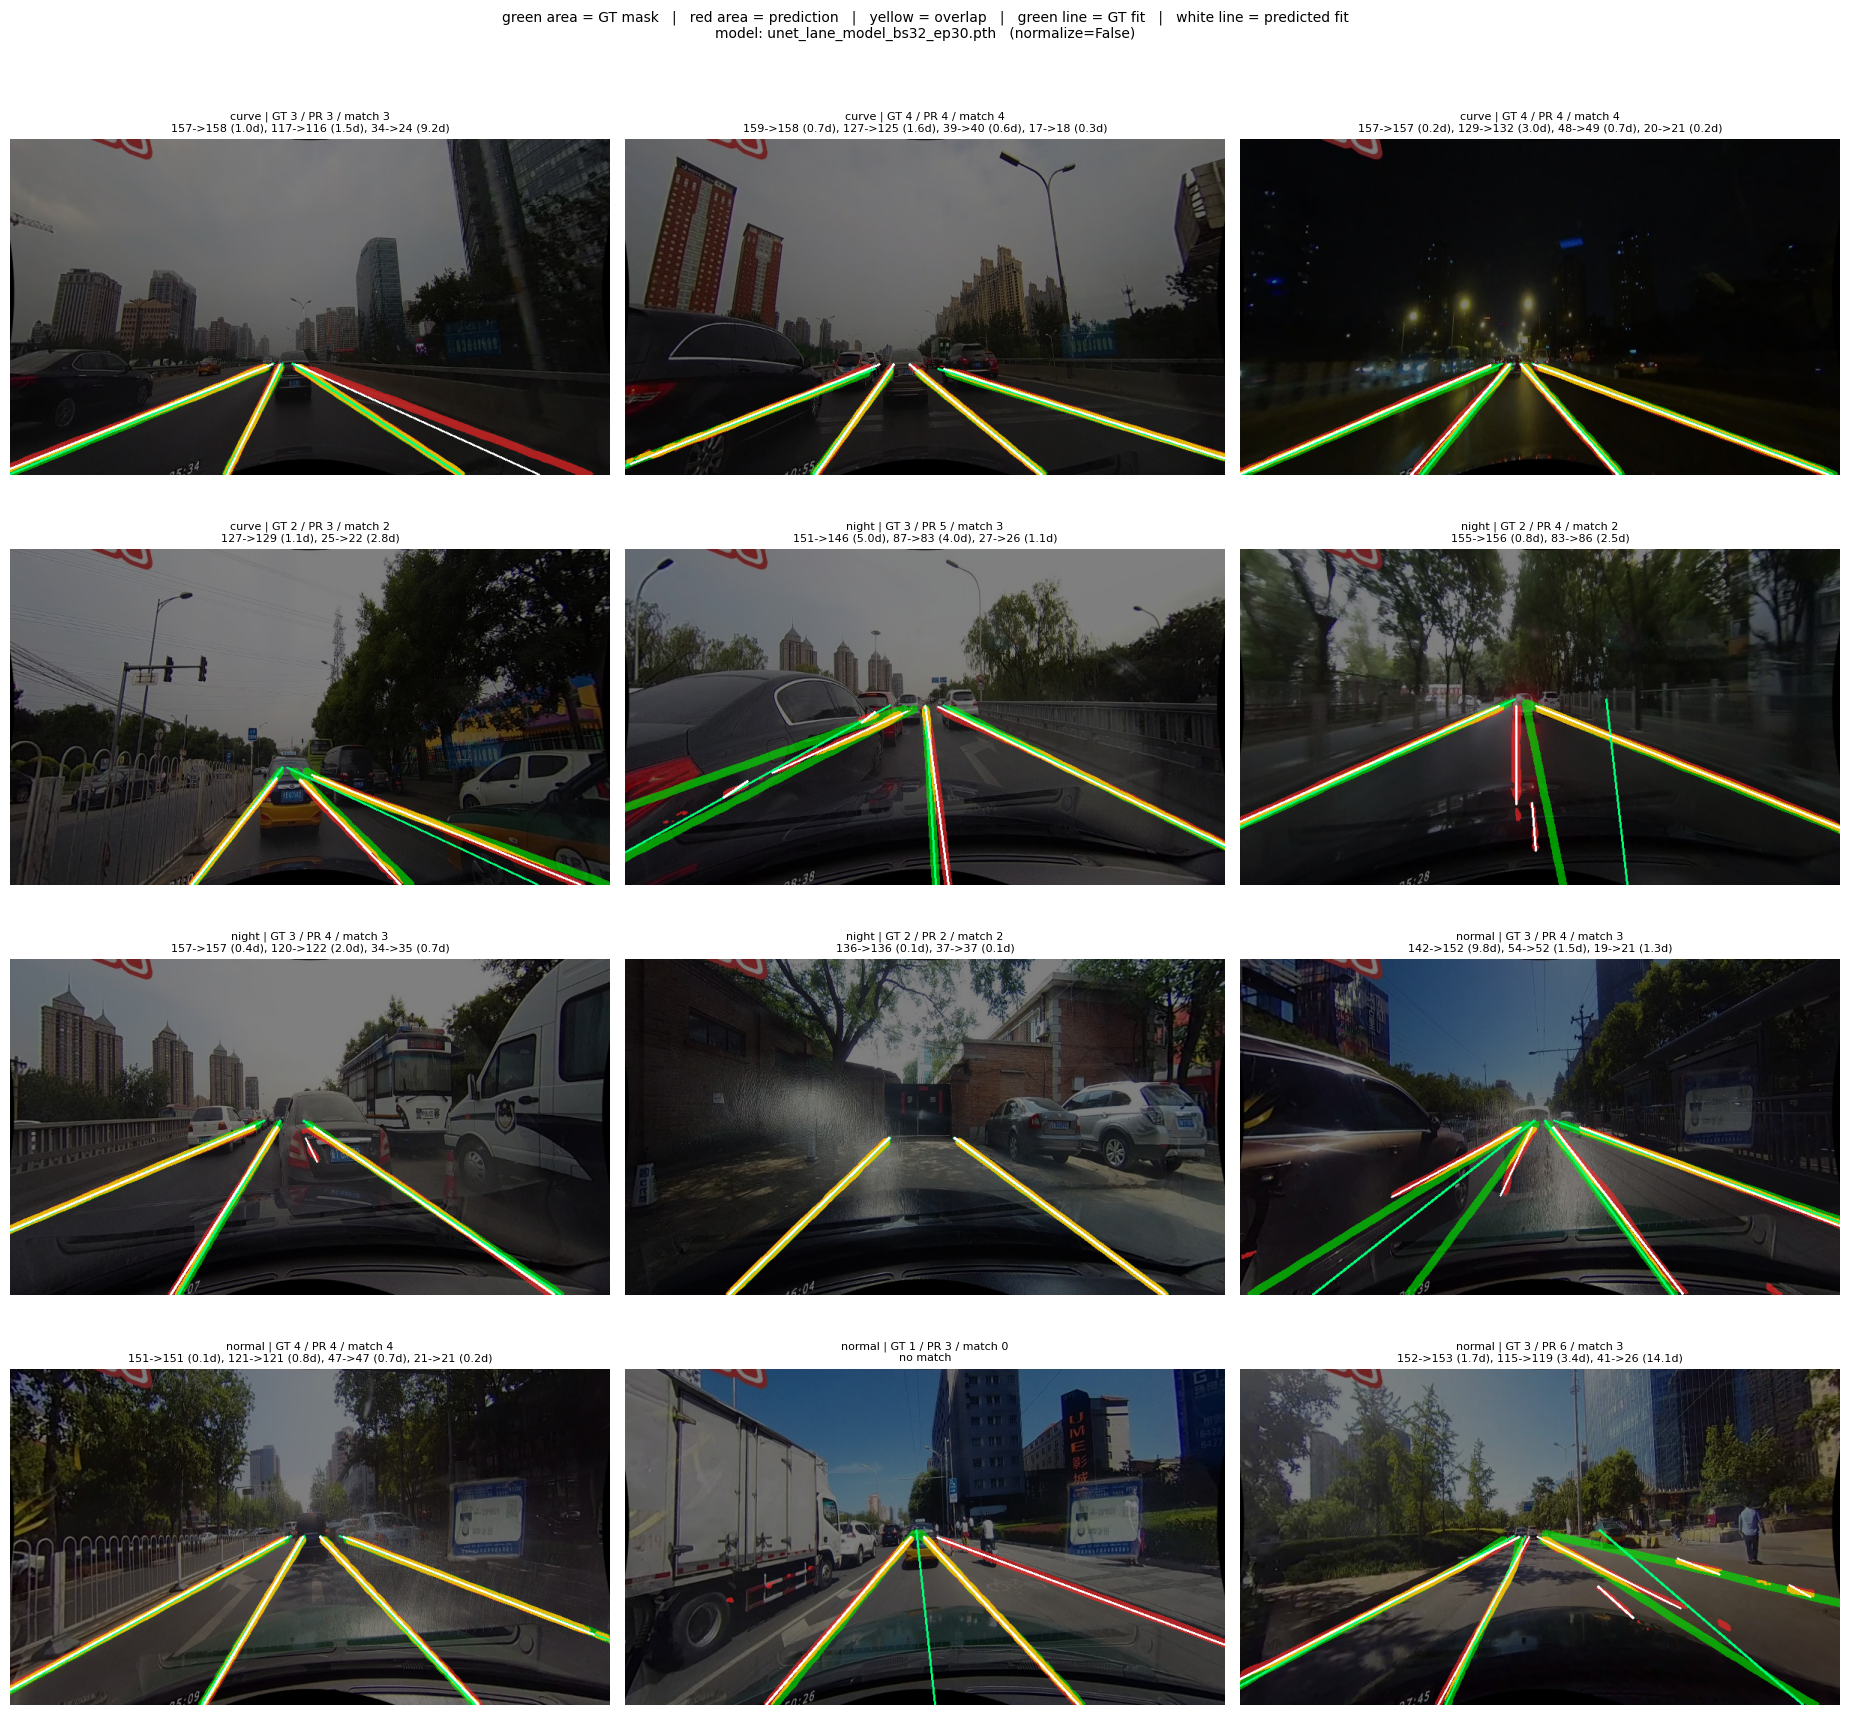

[(1326, 'curve'),
 (617, 'curve'),
 (1617, 'curve'),
 (197, 'curve'),
 (2703, 'night'),
 (4601, 'night'),
 (2792, 'night'),
 (3904, 'night'),
 (5910, 'normal'),
 (13273, 'normal'),
 (8477, 'normal'),
 (5574, 'normal')]

In [19]:
SLOPE_PLOT_N    = 12       # จำนวนภาพ
SLOPE_PLOT_SEED = 7        # เปลี่ยนเลขเพื่อสุ่มชุดใหม่


def plot_slope_blindtest(model_path, encoder_name, dataset_root, use_normalize=False,
                         n_samples=SLOPE_PLOT_N, seed=SLOPE_PLOT_SEED, threshold=0.5,
                         tag=None, use_amp=True):
    import random
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = use_amp and device.type == "cuda"

    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดล: {model_path}")
        return None

    img_dir = os.path.join(dataset_root, "images")
    mask_dir = os.path.join(dataset_root, "masks")
    ds = LaneDatasetFromCSV(os.path.join(dataset_root, "test_list.csv"), img_dir, mask_dir,
                            augment=False)

    # สุ่มให้กระจายทุกหมวดเท่าๆ กัน
    bycat = {}
    for i, (_, c) in enumerate(ds.samples):
        bycat.setdefault(c, []).append(i)
    rng = random.Random(seed)
    cats_sorted = sorted(bycat)
    # แจกโควตาให้ครบ n_samples พอดี เศษที่หารไม่ลงตัวยกให้หมวดแรกๆ
    # (ถ้าใช้ n_samples // len(bycat) เฉยๆ จะได้ภาพไม่ครบ เช่น 8 // 3 = 2 -> ได้แค่ 6 ภาพ)
    base, extra = divmod(n_samples, len(cats_sorted))
    picks = []
    for k, c in enumerate(cats_sorted):
        want = base + (1 if k < extra else 0)
        if want:
            picks += [(i, c) for i in rng.sample(bycat[c], min(want, len(bycat[c])))]
    picks = picks[:n_samples]

    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None, in_channels=3, classes=1)
    obj = torch.load(model_path, map_location="cpu", weights_only=False)
    state = obj["model_state_dict"] if isinstance(obj, dict) and "model_state_dict" in obj else obj
    model.load_state_dict(state)
    model.to(device).eval()
    prep_input = make_input_prep(encoder_name, "imagenet", device,
                                 normalize=use_normalize, channels_last=False)

    cols = 3
    rows_n = int(np.ceil(len(picks) / cols))
    # หัวข้อแต่ละภาพมี 2 บรรทัด ต้องเผื่อความสูงต่อแถวไว้ ไม่งั้นหัวข้อจะถูกภาพแถวบนทับ
    fig, axes = plt.subplots(rows_n, cols, figsize=(6.2 * cols, 4.45 * rows_n))
    axes = np.atleast_1d(axes).ravel()

    for ax, (idx, cat) in zip(axes, picks):
        image_t, mask_t = ds[idx]
        with torch.inference_mode():
            x = image_t.unsqueeze(0).to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logit = model(prep_input(x))
            prob = torch.sigmoid(logit.float())[0, 0].cpu().numpy()

        # ต้อง ascontiguousarray: permute ของ torch ให้ array ที่ไม่ C-contiguous
        # (strides สลับ) และ numpy รักษา memory order นั้นไว้ ทำให้ cv2.line ไม่รับ array
        rgb = np.ascontiguousarray((image_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        gt = mask_t[0].numpy() > 0.5
        pd = prob > threshold

        vis = (rgb * 0.5).astype(np.uint8)
        vis[gt] = (0.35 * vis[gt] + 0.65 * np.array([0, 230, 0])).astype(np.uint8)
        vis[pd] = (0.35 * vis[pd] + 0.65 * np.array([255, 40, 40])).astype(np.uint8)
        vis[gt & pd] = (0.3 * vis[gt & pd] + 0.7 * np.array([255, 230, 0])).astype(np.uint8)

        r = slope_metrics_for_pair(gt, pd)
        for d in r["gt_lanes"]:
            y0, y1 = int(d["y_top"]), int(d["y_bot"])
            cv2.line(vis, (int(d["a"] * y0 + d["b"]), y0), (int(d["a"] * y1 + d["b"]), y1),
                     (0, 255, 120), 2)
        for d in r["pred_lanes"]:
            y0, y1 = int(d["y_top"]), int(d["y_bot"])
            cv2.line(vis, (int(d["a"] * y0 + d["b"]), y0), (int(d["a"] * y1 + d["b"]), y1),
                     (255, 255, 255), 2)

        errtxt = ", ".join(f"{d['gt_ang']:.0f}->{d['pred_ang']:.0f} ({d['err']:.1f}d)"
                           for d in r["pairs"]) or "no match"
        ax.imshow(vis)
        ax.set_title(f"{cat} | GT {r['n_gt']} / PR {r['n_pred']} / match {r['n_matched']}\n{errtxt}",
                     fontsize=8)
        ax.axis("off")

    for ax in axes[len(picks):]:
        ax.axis("off")

    fig.suptitle("green area = GT mask   |   red area = prediction   |   yellow = overlap   |   "
                 "green line = GT fit   |   white line = predicted fit\n"
                 f"model: {os.path.basename(model_path)}   (normalize={use_normalize})",
                 fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.96), h_pad=2.8)
    if tag:
        os.makedirs("results/slope", exist_ok=True)
        out = f"results/slope/slope_blindtest_{tag}.png"
        plt.savefig(out, dpi=110)
        print(f"📁 บันทึกภาพไว้ที่: {out}")
    plt.show()
    return picks


plot_slope_blindtest(model_path=_mp, encoder_name=_enc, dataset_root=DATASET_ROOT,
                     use_normalize=_nz, tag=os.path.splitext(os.path.basename(_mp))[0])

## ตัวเลขความชันเชื่อได้แค่ไหน — null test + baseline

ค่า "มุมคลาด 0.95 องศา" ลอยๆ บอกไม่ได้ว่าดีหรือแย่ ต้องมีสเกลที่มีหัวมีท้ายก่อน

| | คืออะไร |
| --- | --- |
| **null test** (เพดานบน) | เอาเฉลยใส่เป็นคำทำนายเลย **ต้องได้ 0.00° เป๊ะ** ถ้าไม่ใช่แปลว่าโค้ดวัดผลมีบั๊ก อ่านตัวเลขอื่นต่อไม่ได้ |
| **baseline: เดามุมจากตำแหน่ง** | เดามุมจากตำแหน่ง x ของเส้นเท่านั้น **ไม่ดูภาพเลย** — เลนซ้ายเอียงทางหนึ่ง เลนขวาเอียงอีกทาง เดาได้โดยไม่ต้องเรียนรู้ ถ้าโมเดลชนะ baseline นี้ไม่ขาด แปลว่ามันไม่ได้เรียนอะไรมากกว่าการจำตำแหน่ง |
| **สุ่มมุม** (พื้นล่าง) | ค่าที่ควรได้ ~45° |

prior สร้างจาก **train split** ไม่ใช่ test เพื่อไม่ให้ข้อมูลรั่ว

เซลล์นี้ใช้เวลาราว 1 นาที

เซลล์นี้รันเดี่ยวได้ ไม่ต้องรอเซลล์ `evaluate_slope` ด้านบน (แต่ต้องรันเซลล์ import และ CONFIG มาก่อน)


In [ ]:
# ==================== ตั้งค่า null test + baseline ====================
SLOPE_BASE_CHOICE = "old_bs32_ep30"   # เลือกจากตาราง SLOPE_TARGETS ด้านล่าง
SLOPE_BASE_N      = 500               # จำนวนภาพจาก test split
SLOPE_BASE_PRIOR  = 400               # จำนวนภาพจาก train split ที่ใช้สร้าง prior
SLOPE_BASE_SEED   = 11

# เซลล์นี้รันเดี่ยวๆ ได้ ไม่ต้องรอเซลล์ evaluate_slope (ซึ่งกินเวลา ~2.5 นาที)
# ถ้ายังไม่ได้รันเซลล์นั้น ก็สร้างตารางโมเดลขึ้นมาเองตรงนี้
if "SLOPE_TARGETS" not in dir():
    SLOPE_TARGETS = {
        "new_final":     (f"models/unet_lane_model_{EXP_NAME}.pth",    True,  ENCODER_NAME),
        "new_best":      (f"models/best_model_{EXP_NAME}.pth",         True,  ENCODER_NAME),
        "old_bs32_ep30": ("models/unet_lane_model_bs32_ep30.pth",      False, "resnet34"),
        "old_bs32_ep20": ("models/best_unet_lane_model_bs32_ep20.pth", False, "resnet34"),
    }
# ======================================================================


def _stat_line(errs, n_gt, n_match):
    """สรุปสถิติสั้นๆ จากรายการ error (องศา)"""
    e = np.asarray(errs, dtype=np.float64) if len(errs) else np.array([np.nan])
    return dict(median=float(np.median(e)), mean=float(np.mean(e)),
                acc5=float(np.mean(e <= 5.0)) if len(errs) else float("nan"),
                acc10=float(np.mean(e <= 10.0)) if len(errs) else float("nan"),
                recall=(n_match / n_gt) if n_gt else float("nan"),
                n_gt=n_gt, n_matched=n_match)


def evaluate_slope_baselines(model_path, encoder_name, dataset_root, use_normalize=False,
                             n_images=SLOPE_BASE_N, n_prior=SLOPE_BASE_PRIOR,
                             seed=SLOPE_BASE_SEED, threshold=0.5, tag=None, save_csv=True):
    """
    วางผลของโมเดลลงบนสเกล เพดานบน -> baseline -> พื้นล่าง
    เพื่อตอบว่า "มุมคลาดเท่านี้ ดีจริงไหม" ไม่ใช่แค่ดูเลขลอยๆ
    """
    import random
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rng = random.Random(seed)

    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดล: {model_path}")
        return None

    img_dir = os.path.join(dataset_root, "images")
    mask_dir = os.path.join(dataset_root, "masks")

    # ---- 1) สร้าง prior จาก train split (ห้ามใช้ test เดี๋ยวข้อมูลรั่ว) ----
    tr = list(csv.DictReader(open(os.path.join(dataset_root, "train_list.csv"))))
    step = max(1, len(tr) // n_prior)
    prior_masks = []
    for r in tr[::step][:n_prior]:
        m = cv2.imread(os.path.join(mask_dir, r["filename"].replace(".jpg", ".png")),
                       cv2.IMREAD_GRAYSCALE)
        if m is not None:
            prior_masks.append(m > 127)
    prior = AnglePositionPrior(bins=10, width=IMG_SIZE[1]).fit(prior_masks)
    print(f"🧭 prior จาก train {len(prior_masks)} ภาพ — มุมกลางตามตำแหน่ง x (ซ้าย→ขวา):")
    print("   ", [round(v, 1) if v is not None else None for v in prior.table])

    # ---- 2) เตรียมโมเดล ----
    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None, in_channels=3, classes=1)
    obj = torch.load(model_path, map_location="cpu", weights_only=False)
    state = obj["model_state_dict"] if isinstance(obj, dict) and "model_state_dict" in obj else obj
    model.load_state_dict(state)
    model.to(device).eval()
    prep_input = make_input_prep(encoder_name, "imagenet", device,
                                 normalize=use_normalize, channels_last=False)

    # ---- 3) วนภาพจาก test split ----
    ds = LaneDatasetFromCSV(os.path.join(dataset_root, "test_list.csv"), img_dir, mask_dir,
                            augment=False)
    idx = sorted(rng.sample(range(len(ds)), min(n_images, len(ds))))
    schemes = ("null", "model", "prior", "random")
    acc = {k: dict(e=[], gt=0, m=0) for k in schemes}
    iou_model = []

    for i in tqdm(idx, desc="[baselines]", leave=False):
        image_t, mask_t = ds[i]
        gt = mask_t[0].numpy() > 0.5
        with torch.inference_mode():
            logit = model(prep_input(image_t.unsqueeze(0).to(device)))
        pd = torch.sigmoid(logit.float())[0, 0].cpu().numpy() > threshold
        iou_model.append(mask_iou(gt, pd))

        g = extract_lanes(gt)
        for name, plan in (("null", g),
                           ("model", extract_lanes(pd)),
                           ("prior", prior.as_pred_lanes(g)),
                           ("random", prior.as_random_lanes(g, rng))):
            r = slope_metrics_for_lanes(g, plan)
            acc[name]["gt"] += r["n_gt"]
            acc[name]["m"] += r["n_matched"]
            acc[name]["e"] += [d["err"] for d in r["pairs"]]

    rows = []
    label = {"null": "เพดานบน: เฉลย vs เฉลย", "model": "โมเดลจริง",
             "prior": "baseline: เดามุมจากตำแหน่ง", "random": "พื้นล่าง: สุ่มมุม"}
    for k in schemes:
        st = _stat_line(acc[k]["e"], acc[k]["gt"], acc[k]["m"])
        rows.append(dict(scheme=k, label=label[k], **st))

    print(f"\n📏 สเกลความชัน (test {len(idx)} ภาพ, โมเดล {os.path.basename(model_path)})")
    print(f"{'':32s} {'median':>8s} {'mean':>7s} {'acc@5°':>8s} {'recall':>7s}")
    print("-" * 68)
    for r in rows:
        print(f"  {r['label']:30s} {r['median']:7.2f}° {r['mean']:6.2f}° "
              f"{r['acc5']*100:7.1f}% {r['recall']:7.3f}")

    null_row = rows[0]
    ok = null_row["median"] < 1e-9 and abs(null_row["recall"] - 1.0) < 1e-9
    print(f"\n  null test: {'✅ ผ่าน (0.00° และจับคู่ครบ)' if ok else '❌ ไม่ผ่าน — อย่าเชื่อตัวเลขด้านบน'}")

    m_med, p_med = rows[1]["median"], rows[2]["median"]
    if m_med > 0:
        print(f"  โมเดลลดความคลาดจาก baseline ได้ {p_med / m_med:.1f} เท่า "
              f"({p_med:.2f}° → {m_med:.2f}°)")
        print(f"  เดินทางจาก baseline ไปถึงเพดานได้ {(p_med - m_med) / p_med * 100:.0f}%")
    print(f"  IoU ของโมเดลบนภาพชุดเดียวกัน = {np.mean(iou_model):.3f}")

    if save_csv and tag:
        os.makedirs("results/slope", exist_ok=True)
        out = f"results/slope/slope_baselines_{tag}.csv"
        with open(out, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader()
            for r in rows:
                w.writerow(r)
        print(f"\n📁 บันทึกผลไว้ที่: {out}")
    return rows


_bmp, _bnz, _benc = SLOPE_TARGETS[SLOPE_BASE_CHOICE]
baseline_rows = evaluate_slope_baselines(
    model_path=_bmp, encoder_name=_benc, dataset_root=DATASET_ROOT,
    use_normalize=_bnz, tag=os.path.splitext(os.path.basename(_bmp))[0],
)